# Random Forest Regressor — An Illustrated Tour

> A **forest** of diverse decision trees, each trained on a random data subset, whose predictions are averaged to reduce variance.

---

**What we cover:**
- A single decision tree — and why deep trees overfit
- Bootstrap sampling — creating diverse trees
- Random feature selection — decorrelating the trees
- The ensemble average — wisdom of the crowd
- Stability as the forest grows
- Feature importance

## The picture — many noisy trees averaged into a smooth piecewise-constant fit

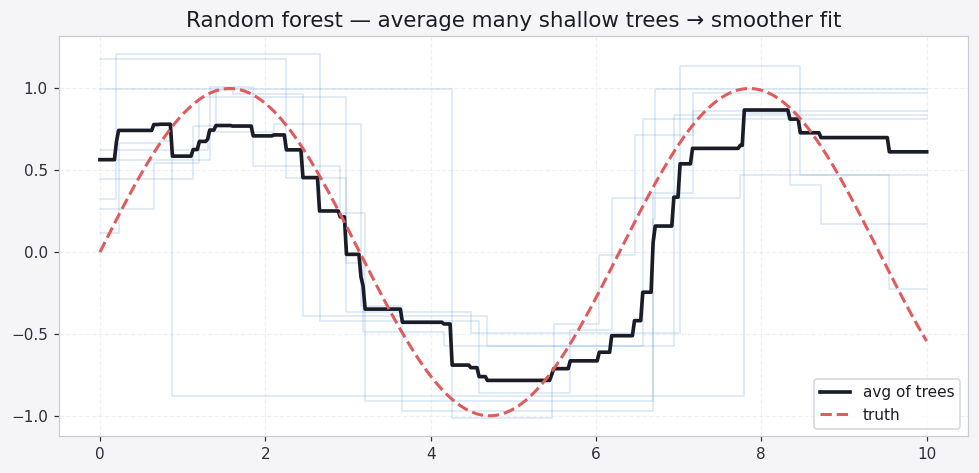

In [1]:
# (schematic — drawn from smooth curves, not measured)
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrow, FancyBboxPatch, Ellipse, Rectangle, Circle, FancyArrowPatch
plt.rcParams.update({
    'figure.facecolor':'#f5f5f7','axes.facecolor':'#ffffff','axes.edgecolor':'#c8ccd4',
    'axes.labelcolor':'#1a1d27','axes.titlecolor':'#1a1d27','xtick.color':'#2a2e3a',
    'ytick.color':'#2a2e3a','grid.color':'#e0e3ea','grid.linestyle':'--','grid.alpha':0.5,
    'text.color':'#1a1d27','font.family':'DejaVu Sans','axes.titlesize':14,'axes.labelsize':12,
    'legend.facecolor':'#ffffff','legend.edgecolor':'#c8ccd4','figure.dpi':110,
})
P = ['#5b9bd5','#e05c5c','#f4b942','#7ecba1','#56b6c2','#c678dd','#888fa5','#d68a3c']
rng = np.random.RandomState(0)
x = np.linspace(0, 10, 400); ytrue = np.sin(x)
fig, ax = plt.subplots(figsize=(9, 4.4))
trees = []
for k in range(8):
    cuts = np.sort(rng.uniform(0, 10, 6))
    edges = np.concatenate([[0], cuts, [10]])
    vals  = np.sin((edges[:-1]+edges[1:])/2) + 0.15*rng.randn(len(edges)-1)
    yk = np.zeros_like(x)
    for i in range(len(vals)): yk[(x>=edges[i])&(x<edges[i+1])] = vals[i]
    yk[-1] = vals[-1]
    ax.step(x, yk, where='post', color=P[0], alpha=0.25, lw=1)
    trees.append(yk)
ax.plot(x, np.mean(trees, axis=0), color='#1a1d27', lw=2.4, label='avg of trees')
ax.plot(x, ytrue, color=P[1], lw=2, ls='--', label='truth')
ax.set_title('Random forest — average many shallow trees → smoother fit')
ax.legend(); ax.grid(True); plt.tight_layout(); plt.show()


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error

# ── Presentation style ─────────────────────────────────────────────────────
PLT_STYLE = {
    'figure.facecolor':'#f5f5f7', 'axes.facecolor':'#ffffff',
    'axes.edgecolor':'#c8ccd4',   'axes.labelcolor':'#1a1d27',
    'axes.titlecolor':'#1a1d27',  'xtick.color':'#2a2e3a',
    'ytick.color':'#2a2e3a',      'grid.color':'#e0e3ea',
    'grid.linestyle': '--',        'grid.alpha': 0.5,
    'text.color':'#1a1d27',       'font.family': 'DejaVu Sans',
    'axes.titlesize': 17,          'axes.labelsize': 13,
    'xtick.labelsize': 11,         'ytick.labelsize': 11,
    'legend.fontsize': 11,         'legend.facecolor':'#ffffff',
    'legend.edgecolor':'#c8ccd4', 'figure.dpi': 120,
}
plt.rcParams.update(PLT_STYLE)

C_DATA  = '#5b9bd5'   # data points
C_TREE  = '#e05c5c'   # single tree / deep tree
C_RF    = '#f4b942'   # random forest
C_TRUE  = '#7ecba1'   # true function
C_HL    = '#56b6c2'   # highlight
C_GRAD  = '#c678dd'   # gradient colour

# ── Dataset: non-linear signal ─────────────────────────────────────────────
np.random.seed(0)
m      = 80
x_raw  = np.sort(np.random.uniform(0, 6, m))
y_raw  = np.sin(x_raw) + 0.5 * np.cos(2*x_raw) + np.random.randn(m) * 0.35

x_pl   = np.linspace(0, 6, 400)
y_true = np.sin(x_pl) + 0.5 * np.cos(2*x_pl)

print(f'Dataset: {m} points  |  non-linear signal: sin(x) + 0.5·cos(2x) + noise')

Dataset: 80 points  |  non-linear signal: sin(x) + 0.5·cos(2x) + noise


---
## The Building Block: A Decision Tree

A **decision tree** partitions the input space into rectangular regions and predicts the mean response within each region.
Shallow trees underfit; deep trees memorise noise.

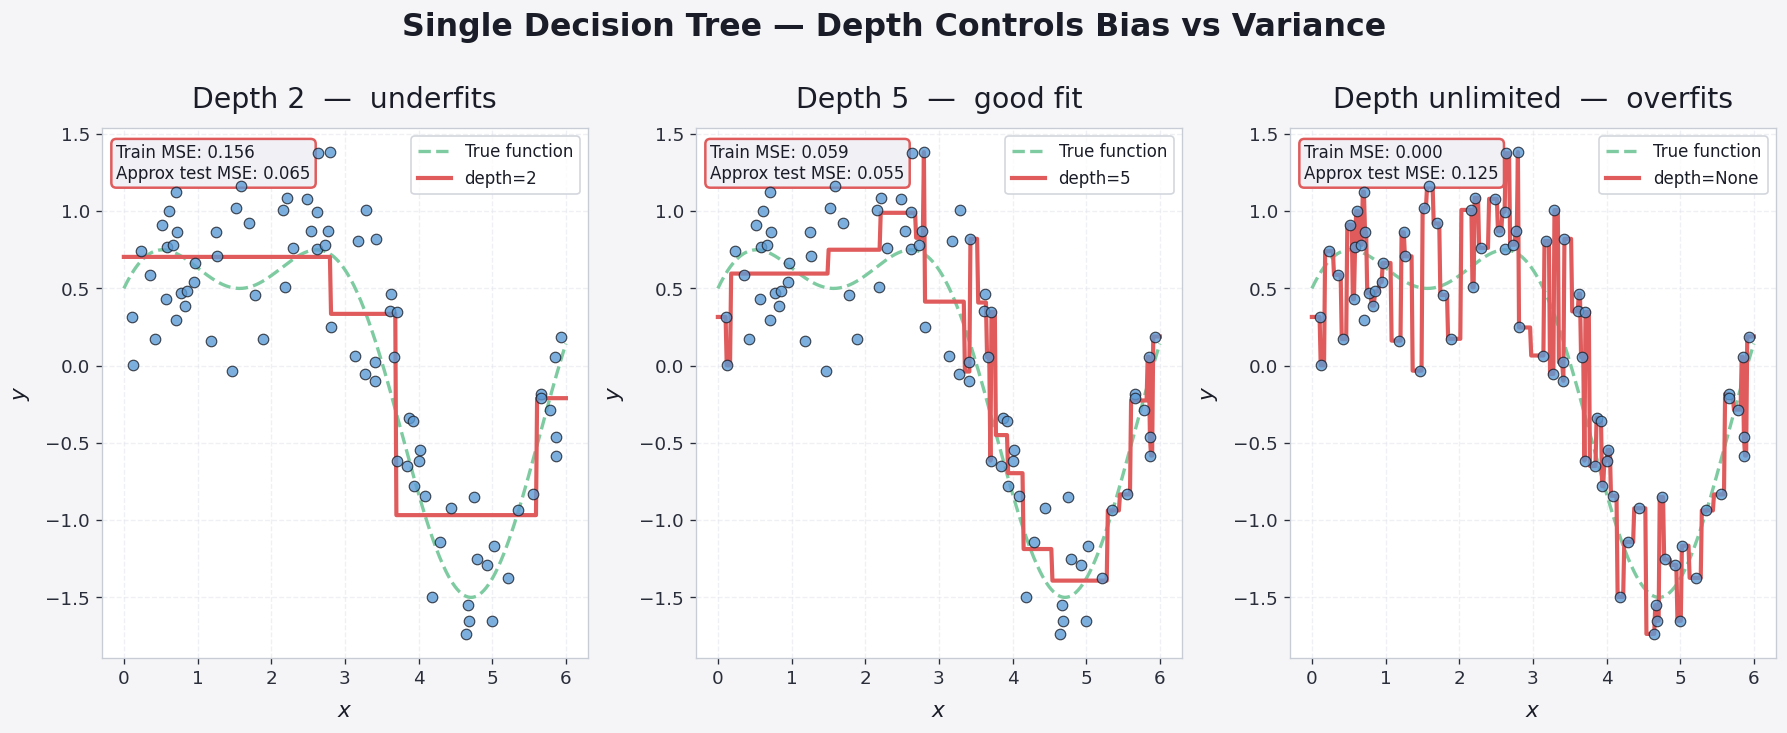

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 6))

for ax, depth, title in zip(axes,
    [2, 5, None],
    ['Depth 2  —  underfits', 'Depth 5  —  good fit', 'Depth unlimited  —  overfits']):

    tree = DecisionTreeRegressor(max_depth=depth, random_state=0)
    tree.fit(x_raw.reshape(-1,1), y_raw)

    train_mse = mean_squared_error(y_raw, tree.predict(x_raw.reshape(-1,1)))
    test_mse  = mean_squared_error(y_true, tree.predict(x_pl.reshape(-1,1)))

    ax.plot(x_pl, y_true, color=C_TRUE, lw=2, ls='--', label='True function', zorder=2)
    ax.plot(x_pl, tree.predict(x_pl.reshape(-1,1)),
            color=C_TREE, lw=2.5, label=f'depth={depth}', zorder=3)
    ax.scatter(x_raw, y_raw, s=40, c=C_DATA, edgecolors='#1a1d27', lw=0.7,
               alpha=0.8, zorder=4)
    ax.set_xlabel('$x$', labelpad=8); ax.set_ylabel('$y$', labelpad=8)
    ax.set_title(title, pad=12)
    ax.grid(True); ax.legend(loc='upper right', fontsize=10)
    ax.text(0.03, 0.97, f'Train MSE: {train_mse:.3f}\nApprox test MSE: {test_mse:.3f}',
            transform=ax.transAxes, fontsize=10, va='top',
            bbox=dict(boxstyle='round', fc='#f0f0f5', ec=C_TREE, lw=1.5))

fig.suptitle('Single Decision Tree — Depth Controls Bias vs Variance',
             fontsize=19, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

---
## Bootstrap Sampling — Diversity Through Resampling

Each tree in the forest sees a **different bootstrap sample**: $m$ points drawn *with replacement* from the training set.
This creates diverse trees — each makes different mistakes — so their average is better than any single one.

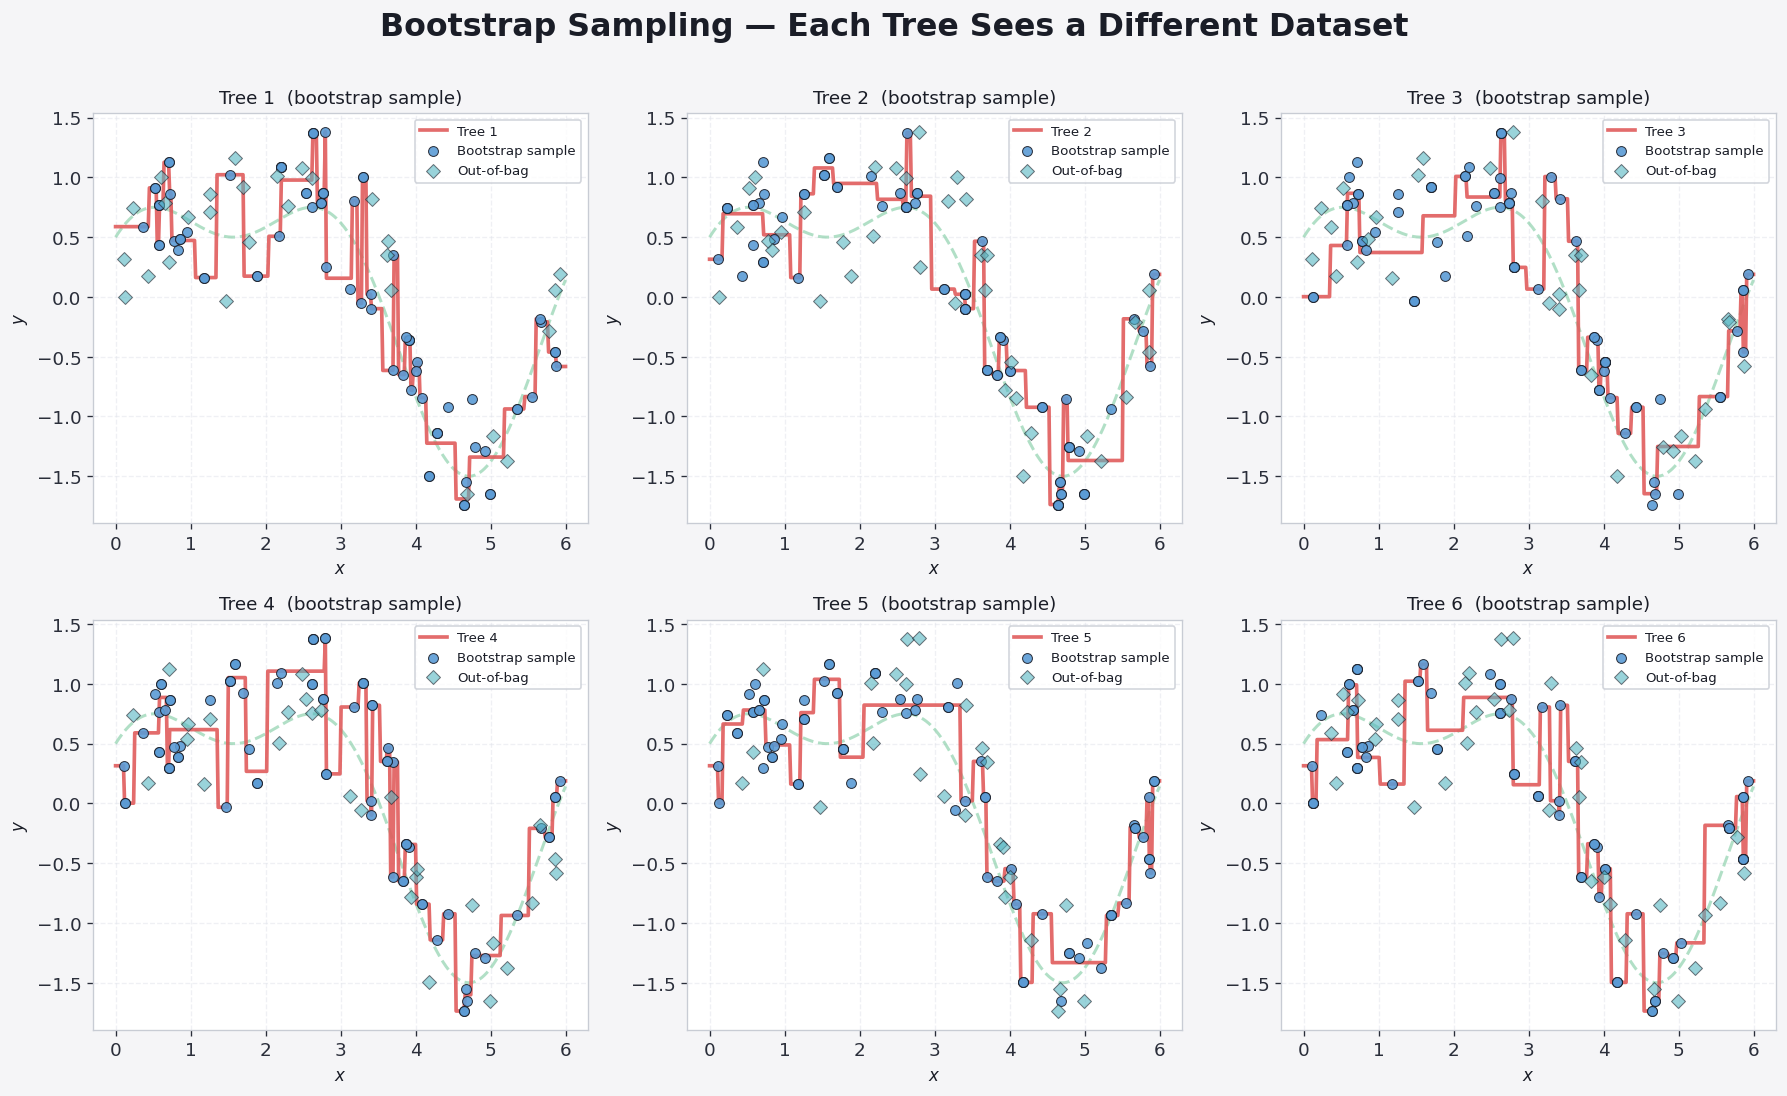

In [4]:
rng = np.random.default_rng(42)
n_show = 6

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

boot_preds = []
for i, ax in enumerate(axes):
    # Bootstrap sample
    idx_boot = rng.integers(0, m, size=m)
    x_b, y_b = x_raw[idx_boot], y_raw[idx_boot]
    oob_mask = np.ones(m, dtype=bool)
    oob_mask[np.unique(idx_boot)] = False    # out-of-bag points

    tree = DecisionTreeRegressor(max_depth=6, random_state=i)
    tree.fit(x_b.reshape(-1,1), y_b)
    pred = tree.predict(x_pl.reshape(-1,1))
    boot_preds.append(pred)

    ax.plot(x_pl, y_true, color=C_TRUE, lw=1.8, ls='--', alpha=0.6)
    ax.plot(x_pl, pred,   color=C_TREE, lw=2.2, alpha=0.9,
            label=f'Tree {i+1}')
    ax.scatter(x_b, y_b, s=35, c=C_DATA, edgecolors='#1a1d27', lw=0.6,
               alpha=0.9, zorder=4, label='Bootstrap sample')
    if oob_mask.any():
        ax.scatter(x_raw[oob_mask], y_raw[oob_mask], s=35, c=C_HL,
                   edgecolors='#1a1d27', lw=0.6, alpha=0.6, marker='D',
                   zorder=4, label='Out-of-bag')
    ax.set_xlabel('$x$', fontsize=10); ax.set_ylabel('$y$', fontsize=10)
    ax.set_title(f'Tree {i+1}  (bootstrap sample)', fontsize=11)
    ax.grid(True); ax.legend(loc='upper right', fontsize=8)

fig.suptitle('Bootstrap Sampling — Each Tree Sees a Different Dataset',
             fontsize=19, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

---
## The Ensemble Average

Averaging many diverse trees **cancels out** their individual errors.
Each tree has high variance; the average has much lower variance — with roughly the same bias.

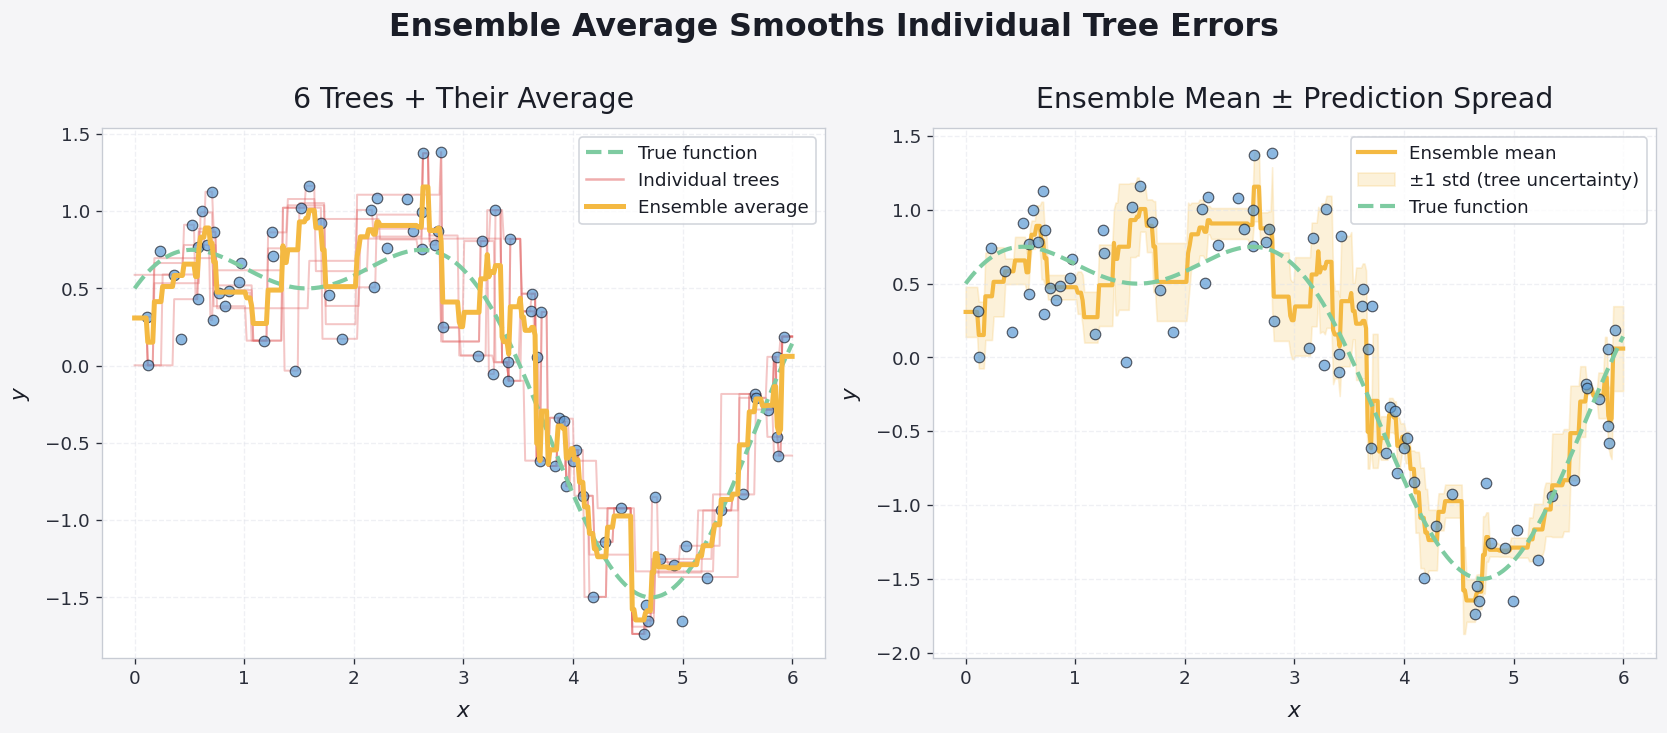

In [5]:
boot_preds_arr = np.array(boot_preds)  # (n_trees, n_plot_points)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: individual trees + ensemble
ax = axes[0]
for pred in boot_preds_arr:
    ax.plot(x_pl, pred, color=C_TREE, lw=1.2, alpha=0.35)
ensemble_6 = boot_preds_arr.mean(axis=0)
ax.plot(x_pl, y_true,     color=C_TRUE, lw=2.5, ls='--', label='True function', zorder=4)
ax.plot(x_pl, ensemble_6, color=C_RF,   lw=3,   label=f'Ensemble avg (6 trees)', zorder=5)
ax.scatter(x_raw, y_raw, s=40, c=C_DATA, edgecolors='#1a1d27', lw=0.7, alpha=0.7, zorder=3)
from matplotlib.lines import Line2D
ax.legend(handles=[
    Line2D([0],[0], color=C_TRUE, lw=2.5, ls='--', label='True function'),
    Line2D([0],[0], color=C_TREE, lw=1.5, alpha=0.5, label='Individual trees'),
    Line2D([0],[0], color=C_RF,   lw=3,   label='Ensemble average'),
], loc='upper right')
ax.set_xlabel('$x$', labelpad=8); ax.set_ylabel('$y$', labelpad=8)
ax.set_title('6 Trees + Their Average', pad=12); ax.grid(True)

# Right: prediction std (uncertainty) across trees
ax = axes[1]
std_6 = boot_preds_arr.std(axis=0)
ax.plot(x_pl, ensemble_6, color=C_RF, lw=2.5, label='Ensemble mean')
ax.fill_between(x_pl, ensemble_6 - std_6, ensemble_6 + std_6,
                color=C_RF, alpha=0.20, label='±1 std (tree uncertainty)')
ax.plot(x_pl, y_true, color=C_TRUE, lw=2.5, ls='--', label='True function', zorder=4)
ax.scatter(x_raw, y_raw, s=40, c=C_DATA, edgecolors='#1a1d27', lw=0.7, alpha=0.7, zorder=3)
ax.set_xlabel('$x$', labelpad=8); ax.set_ylabel('$y$', labelpad=8)
ax.set_title('Ensemble Mean ± Prediction Spread', pad=12)
ax.grid(True); ax.legend(loc='upper right')

fig.suptitle('Ensemble Average Smooths Individual Tree Errors',
             fontsize=19, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

---
## Stability — More Trees, Less Variance

As we add more trees, the ensemble prediction **stabilises** and the spread across individual predictions shrinks.
The test error decreases rapidly at first, then flattens — there's a point of diminishing returns.

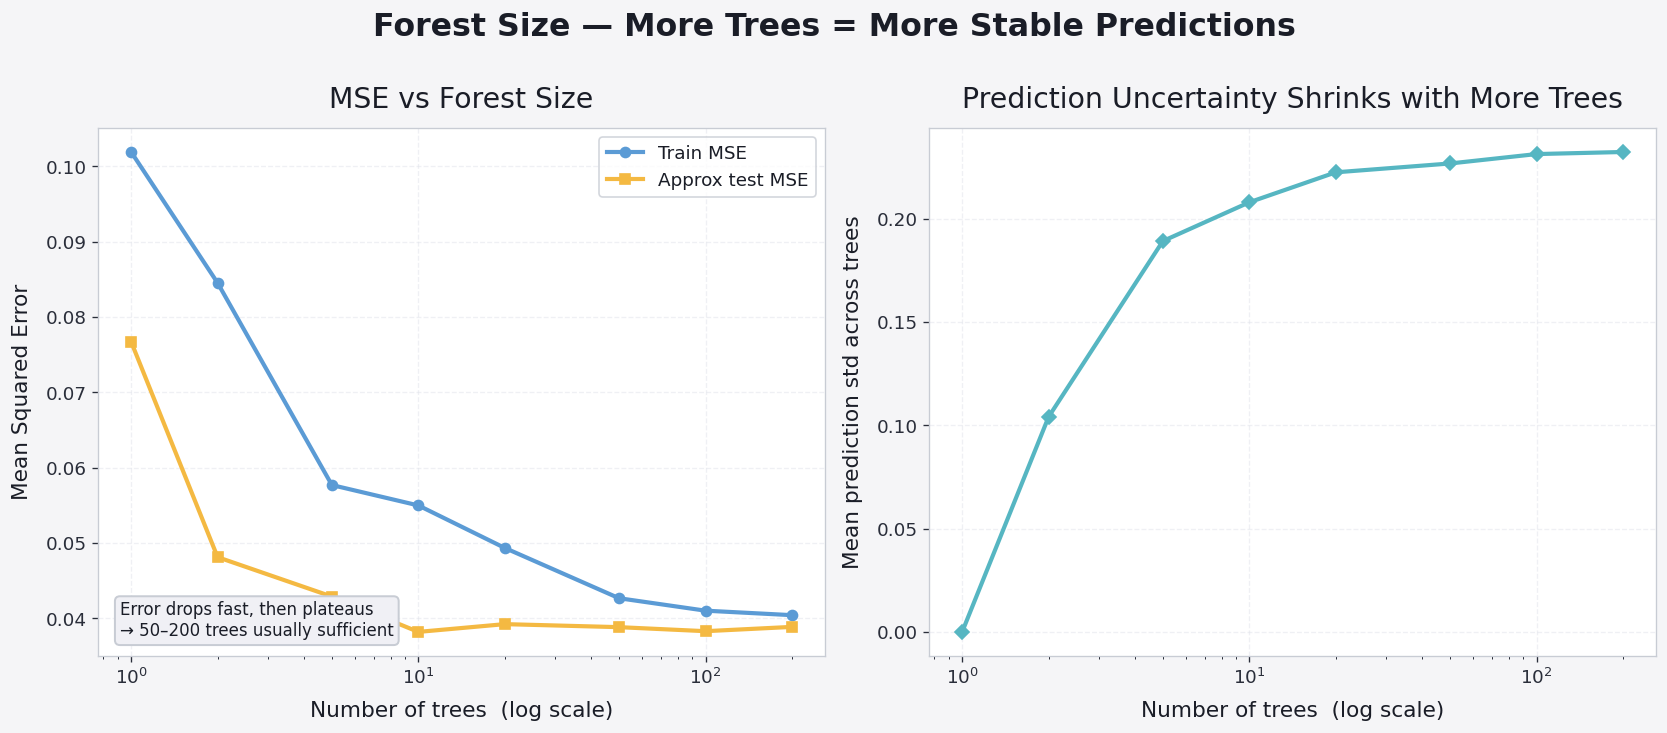

In [6]:
n_estimators_list = [1, 2, 5, 10, 20, 50, 100, 200]
test_mse_rf, train_mse_rf, pred_std_rf = [], [], []

for n_est in n_estimators_list:
    rf = RandomForestRegressor(n_estimators=n_est, max_depth=6,
                               max_features='sqrt', random_state=0)
    rf.fit(x_raw.reshape(-1,1), y_raw)
    preds_plot = np.array([t.predict(x_pl.reshape(-1,1)) for t in rf.estimators_])
    test_mse_rf.append(mean_squared_error(y_true, rf.predict(x_pl.reshape(-1,1))))
    train_mse_rf.append(mean_squared_error(y_raw, rf.predict(x_raw.reshape(-1,1))))
    pred_std_rf.append(preds_plot.std(axis=0).mean())

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: MSE vs n_estimators
ax = axes[0]
ax.semilogx(n_estimators_list, train_mse_rf, color=C_DATA, lw=2.5, marker='o', ms=6,
            label='Train MSE')
ax.semilogx(n_estimators_list, test_mse_rf,  color=C_RF,   lw=2.5, marker='s', ms=6,
            label='Approx test MSE')
ax.set_xlabel('Number of trees  (log scale)', labelpad=8)
ax.set_ylabel('Mean Squared Error', labelpad=8)
ax.set_title('MSE vs Forest Size', pad=12)
ax.grid(True); ax.legend(loc='upper right')
ax.text(0.03, 0.03, 'Error drops fast, then plateaus\n→ 50–200 trees usually sufficient',
        transform=ax.transAxes, fontsize=10, va='bottom',
        bbox=dict(boxstyle='round', fc='#f0f0f5', ec='#c8ccd4', lw=1.2))

# Right: prediction std vs n_estimators
ax = axes[1]
ax.semilogx(n_estimators_list, pred_std_rf, color=C_HL, lw=2.5, marker='D', ms=6)
ax.set_xlabel('Number of trees  (log scale)', labelpad=8)
ax.set_ylabel('Mean prediction std across trees', labelpad=8)
ax.set_title('Prediction Uncertainty Shrinks with More Trees', pad=12)
ax.grid(True)

fig.suptitle('Forest Size — More Trees = More Stable Predictions',
             fontsize=19, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

---
## 🎛️ Try It Yourself — Dial the Forest

Move **n_estimators** (how many trees) and **max_depth** (how complex each tree
is). Watch the live fit on the left and the bias-variance position marker on
the right.

- **Few shallow trees** → high bias, smooth underfit
- **Many deep trees** → low bias but each tree wiggles; the *average* still
  smooths most of it out
- **One deep tree** → the classic overfit, no ensemble smoothing


---
## Feature Importance

A Random Forest can rank features by how much they **reduce impurity** (MSE for regression) on average when used to split nodes.
Features used early and often at the top of many trees receive higher importance.

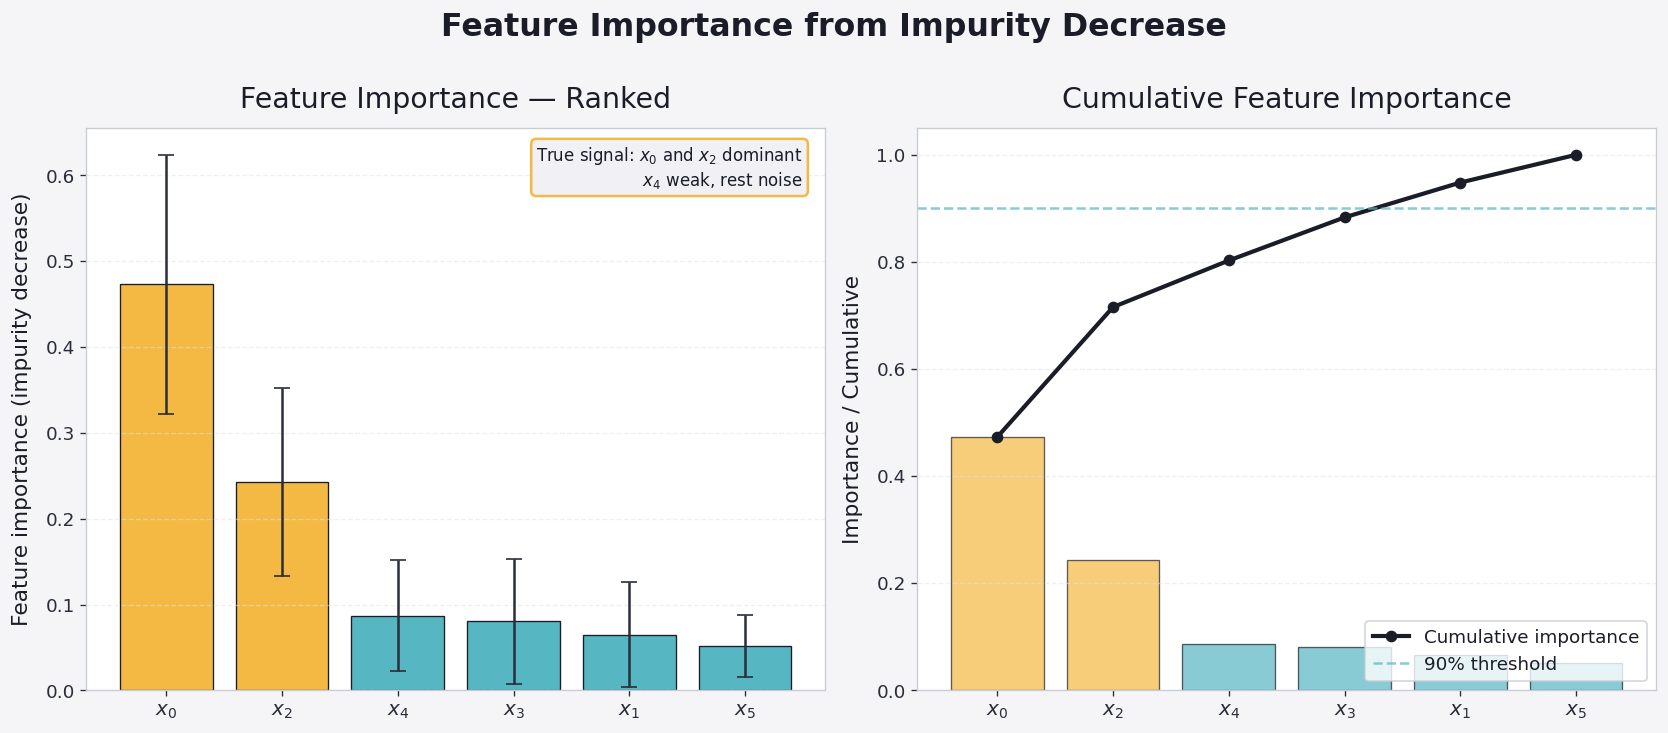

In [7]:
# Multi-feature dataset to demonstrate importance
np.random.seed(1)
m2   = 200
x_mf = np.random.randn(m2, 6)   # 6 features
# y depends mostly on x0 and x2, weakly on x4, not at all on x1, x3, x5
y_mf = (3*x_mf[:,0] - 2*x_mf[:,2]**2 + 0.5*x_mf[:,4]
        + 0.3*np.random.randn(m2))

rf_imp = RandomForestRegressor(n_estimators=200, max_depth=8,
                               max_features='sqrt', random_state=42)
rf_imp.fit(x_mf, y_mf)
importances = rf_imp.feature_importances_
std_imp     = np.std([t.feature_importances_ for t in rf_imp.estimators_], axis=0)

feature_names = [f'$x_{j}$' for j in range(6)]
sort_idx = np.argsort(importances)[::-1]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: importance bar chart
ax = axes[0]
cols = [C_RF if importances[i] > 0.1 else C_HL if importances[i] > 0.02 else '#3a3d60'
        for i in sort_idx]
ax.bar(range(6), importances[sort_idx], yerr=std_imp[sort_idx],
       color=cols, edgecolor='#1a1d27', lw=0.8,
       error_kw=dict(ecolor='#2a2e3a', capsize=5, lw=1.5))
ax.set_xticks(range(6))
ax.set_xticklabels([feature_names[i] for i in sort_idx], fontsize=12)
ax.set_ylabel('Feature importance (impurity decrease)', labelpad=8)
ax.set_title('Feature Importance — Ranked', pad=12)
ax.grid(True, axis='y')
ax.text(0.97, 0.97, 'True signal: $x_0$ and $x_2$ dominant\n$x_4$ weak, rest noise',
        transform=ax.transAxes, fontsize=10, va='top', ha='right',
        bbox=dict(boxstyle='round', fc='#f0f0f5', ec=C_RF, lw=1.5))

# Right: cumulative importance
ax = axes[1]
cumsum = np.cumsum(importances[sort_idx])
ax.bar(range(6), importances[sort_idx], color=cols, edgecolor='#1a1d27', lw=0.8, alpha=0.7)
ax.plot(range(6), cumsum, color='#1a1d27', lw=2.5, marker='o', ms=6,
        label='Cumulative importance')
ax.axhline(0.9, color=C_HL, ls='--', lw=1.5, alpha=0.7, label='90% threshold')
ax.set_xticks(range(6))
ax.set_xticklabels([feature_names[i] for i in sort_idx], fontsize=12)
ax.set_ylabel('Importance / Cumulative', labelpad=8)
ax.set_title('Cumulative Feature Importance', pad=12)
ax.grid(True, axis='y'); ax.legend(loc='lower right')
ax.set_ylim(0, 1.05)

fig.suptitle('Feature Importance from Impurity Decrease',
             fontsize=19, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

---
## Everything on One Canvas

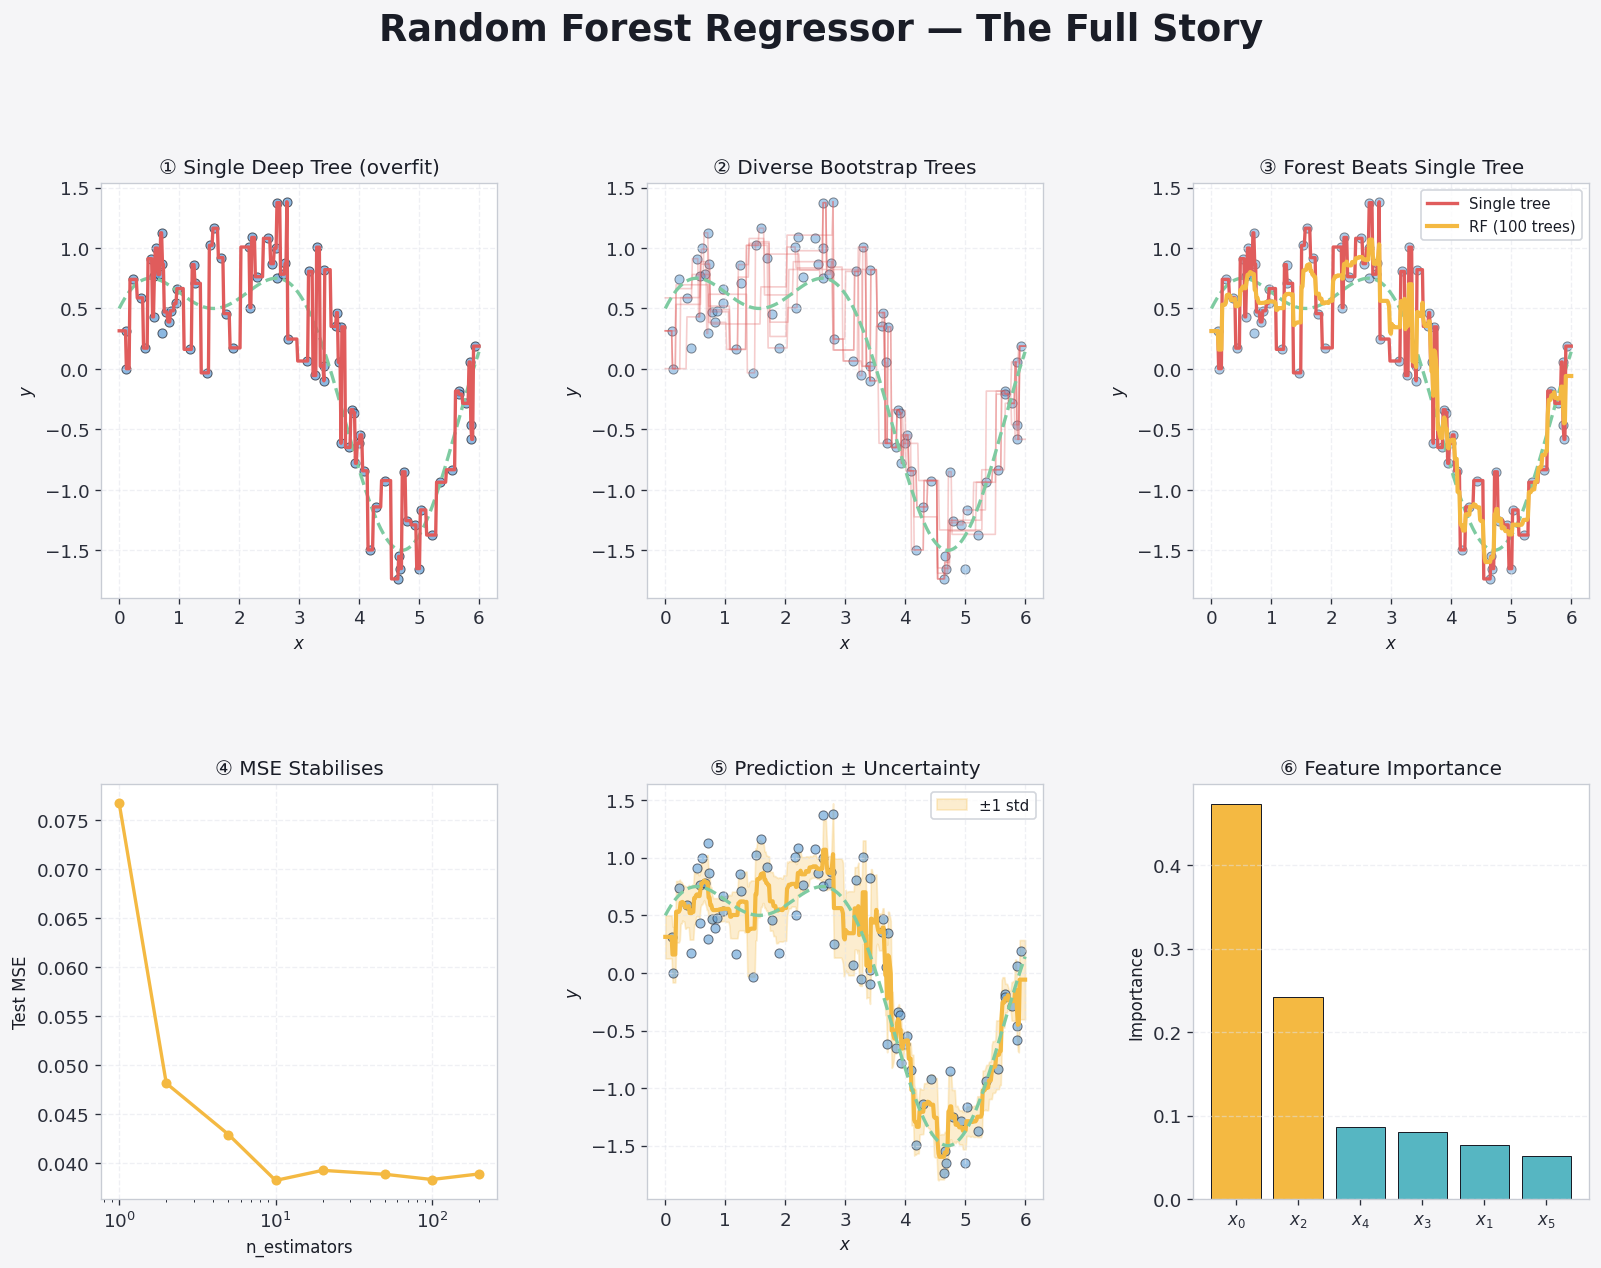

In [8]:
rf_final = RandomForestRegressor(n_estimators=100, max_depth=6,
                                  max_features='sqrt', random_state=0)
rf_final.fit(x_raw.reshape(-1,1), y_raw)
pred_rf_final = rf_final.predict(x_pl.reshape(-1,1))

tree_single = DecisionTreeRegressor(max_depth=None, random_state=0)
tree_single.fit(x_raw.reshape(-1,1), y_raw)

fig = plt.figure(figsize=(16, 11), facecolor='#f5f5f7')
gs  = GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.38)

# ── (0,0) Single deep tree ────────────────────────────────────────────────
ax = fig.add_subplot(gs[0, 0])
ax.plot(x_pl, y_true, color=C_TRUE, lw=2, ls='--')
ax.plot(x_pl, tree_single.predict(x_pl.reshape(-1,1)), color=C_TREE, lw=2)
ax.scatter(x_raw, y_raw, s=30, c=C_DATA, edgecolors='#1a1d27', lw=0.6, alpha=0.7)
ax.grid(True)
ax.set_title('① Single Deep Tree (overfit)', fontsize=12)
ax.set_xlabel('$x$', fontsize=10); ax.set_ylabel('$y$', fontsize=10)

# ── (0,1) Individual trees ────────────────────────────────────────────────
ax = fig.add_subplot(gs[0, 1])
for pred in boot_preds_arr:
    ax.plot(x_pl, pred, color=C_TREE, lw=1, alpha=0.3)
ax.plot(x_pl, y_true, color=C_TRUE, lw=2, ls='--')
ax.scatter(x_raw, y_raw, s=30, c=C_DATA, edgecolors='#1a1d27', lw=0.6, alpha=0.5)
ax.grid(True)
ax.set_title('② Diverse Bootstrap Trees', fontsize=12)
ax.set_xlabel('$x$', fontsize=10); ax.set_ylabel('$y$', fontsize=10)

# ── (0,2) Ensemble vs single tree ────────────────────────────────────────
ax = fig.add_subplot(gs[0, 2])
ax.plot(x_pl, y_true,       color=C_TRUE, lw=2, ls='--')
ax.plot(x_pl, tree_single.predict(x_pl.reshape(-1,1)), color=C_TREE, lw=2, label='Single tree')
ax.plot(x_pl, pred_rf_final, color=C_RF,   lw=2.5, label='RF (100 trees)')
ax.scatter(x_raw, y_raw, s=30, c=C_DATA, edgecolors='#1a1d27', lw=0.6, alpha=0.5)
ax.grid(True); ax.legend(fontsize=9, loc='upper right')
ax.set_title('③ Forest Beats Single Tree', fontsize=12)
ax.set_xlabel('$x$', fontsize=10); ax.set_ylabel('$y$', fontsize=10)

# ── (1,0) MSE vs n_estimators ────────────────────────────────────────────
ax = fig.add_subplot(gs[1, 0])
ax.semilogx(n_estimators_list, test_mse_rf, color=C_RF, lw=2, marker='o', ms=5)
ax.set_title('④ MSE Stabilises', fontsize=12)
ax.set_xlabel('n_estimators', fontsize=10); ax.set_ylabel('Test MSE', fontsize=10)
ax.grid(True)

# ── (1,1) Uncertainty band ────────────────────────────────────────────────
ax = fig.add_subplot(gs[1, 1])
all_preds = np.array([t.predict(x_pl.reshape(-1,1)) for t in rf_final.estimators_])
std_band = all_preds.std(axis=0)
ax.fill_between(x_pl, pred_rf_final - std_band, pred_rf_final + std_band,
                color=C_RF, alpha=0.25, label='±1 std')
ax.plot(x_pl, pred_rf_final, color=C_RF, lw=2.5)
ax.plot(x_pl, y_true, color=C_TRUE, lw=2, ls='--')
ax.scatter(x_raw, y_raw, s=30, c=C_DATA, edgecolors='#1a1d27', lw=0.6, alpha=0.6)
ax.grid(True); ax.legend(fontsize=9)
ax.set_title('⑤ Prediction ± Uncertainty', fontsize=12)
ax.set_xlabel('$x$', fontsize=10); ax.set_ylabel('$y$', fontsize=10)

# ── (1,2) Feature importance ─────────────────────────────────────────────
ax = fig.add_subplot(gs[1, 2])
ax.bar(range(6), importances[sort_idx], color=cols, edgecolor='#1a1d27', lw=0.6)
ax.set_xticks(range(6))
ax.set_xticklabels([feature_names[i] for i in sort_idx], fontsize=10)
ax.set_title('⑥ Feature Importance', fontsize=12)
ax.set_ylabel('Importance', fontsize=10)
ax.grid(True, axis='y')

fig.suptitle('Random Forest Regressor — The Full Story',
             fontsize=22, fontweight='bold', color='#1a1d27', y=1.01)
plt.show()

---
## ⚖️ When to use Random Forest — and when not to

| Situation | RF | Gradient Boosting | Linear / GAM | Single Tree |
|---|---|---|---|---|
| Strong baseline, little tuning | ✅ | ❌ needs care | partial | ❌ |
| Best raw accuracy on tabular | usually 2nd | ✅ usually 1st | ❌ | ❌ |
| Smooth extrapolation | ❌ flat outside data | ❌ | ✅ | ❌ |
| Interpretability of one rule | ❌ ensemble | ❌ | ✅ | ✅ |

> Choose RF as your **first non-linear baseline** — it almost always works without tuning. Reach for gradient boosting when you need the last few accuracy points.


---
## 🎯 Try this

1. **Sweep `max_features`.** Train forests with `max_features=1`, `sqrt`, `1.0`. Decorrelation drops as you increase it; variance and bias both shift. Plot test MSE vs `max_features`.
2. **OOB ≈ CV.** Fit with `oob_score=True` and compare to 5-fold CV — they should agree within standard error.
3. **Out-of-range prediction.** Predict at $x$ values **outside** the training range. The forest will be flat (it can't extrapolate). Try adding a linear pre-fit on the residuals.


---
## Summary

| Concept | Description | Key Insight |
|---|---|---|
| Decision tree | Partition input space into rectangles | Shallow = underfit; deep = overfit |
| Bootstrap sample | $m$ points drawn with replacement from training set | Each tree sees ~63% unique points |
| Out-of-bag (OOB) | Points not in a tree's bootstrap sample | Free validation set for each tree |
| Random feature split | At each node, consider only $\sqrt{n}$ random features | Decorrelates trees → lower ensemble variance |
| Ensemble average | $\hat{y} = \frac{1}{T}\sum_t h_t(x)$ | Averaging reduces variance while preserving bias |
| n_estimators | Number of trees | More → more stable; diminishing returns after ~100 |
| max_depth | Controls each tree's complexity | Shallower = lower variance; deeper = lower bias |
| Feature importance | Mean impurity decrease across splits | Identifies which features drive predictions |

**Key insight:** a single deep tree has high variance — it memorises the training set. By averaging many trees, each trained on a different bootstrap sample with random feature selection, the Random Forest dramatically reduces variance while keeping the bias low — a direct application of the bias-variance tradeoff.